# 17 — Emergent factor discovery (5,000-user cohort)

Interpret the already-trained **Real RBM** (`channelB1`, no personality signal ever shown to it) post-hoc, instead of assuming what "personality" is.

- **Movie side**: for each of the 128 hidden units, find top-weighted movies and explain them via genres, release year, MovieLens genome tags, and user free-text tags.
- **User side**: correlate hidden user activations (`H1`) against derived behavioral features (leniency, extremity, activity, genre entropy, contrarian score, popularity bias) — kept separate, not pre-merged, since they are statistically independent axes.
- **Validation**: whatever factor(s) the correlation analysis actually finds get built into a real second channel and tested on the held-out 20% — not just reported as a correlation. Leniency is not assumed correct going in; it competes on equal footing with everything else, including "nothing cleared the bar."

All discovery analysis runs on **train-partition data only** (`mask==1`), consistent with how `H1`, `personality.npy`, and `user_means.npy` were derived in 09b/12b/14b. The 20% test partition is touched only in Part 5c, for the final four-way evaluation.

| Part | Section |
|------|---------|
| 0 | Setup |
| 1 | Movie-side metadata assembly |
| 2 | Movie-side hidden-unit interpretation |
| 3 | User-side behavioral feature table |
| 4 | Correlation analysis (user-side) |
| 5a | Synthesis — name the real factor(s), if any |
| 5b | Build a new channel from the discovered factor(s) |
| 5c | Four-way test-set validation (Real RBM / existing hand-picked personality / naive bias / discovered channel) |

## Part 0 — Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_dir = root / "data"
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)

RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0], dtype=np.float64)
K = len(RATING_LEVELS)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


paths = {
    "W1": proc / "rbmB1_weights_5k.npy",
    "bh1": proc / "rbmB1_bias_hidden_5k.npy",
    "channelB1": proc / "channelB1_softmax.npy",
    "mask": proc / "mask.npy",
    "cohort": proc / "cohort_user_ids.npy",
    "vocab": proc / "movie_vocab.npy",
    "means": proc / "user_means.npy",
    "personality": proc / "personality.npy",
    "mu_global": proc / "mu_global.npy",
    "test": proc / "test_labels.csv",
}
for p in paths.values():
    assert p.exists(), f"Missing {p}"

W1 = np.load(paths["W1"])
bh1 = np.load(paths["bh1"])
channelB1 = np.load(paths["channelB1"], mmap_mode="r")
mask = np.load(paths["mask"], mmap_mode="r")
cohort_user_ids = np.load(paths["cohort"]).astype(int)
movie_vocab = np.load(paths["vocab"]).astype(int)
user_means = np.load(paths["means"]).astype(np.float64)
personality = np.load(paths["personality"]).astype(np.float64)
mu_global = float(np.load(paths["mu_global"]))
test_labels = pd.read_csv(paths["test"])

n_users, n_movies, k_b1 = channelB1.shape
n_hidden = bh1.shape[0]
assert k_b1 == K
assert mask.shape == (n_users, n_movies)
assert W1.shape == (n_movies * K, n_hidden)
assert len(cohort_user_ids) == n_users
assert len(movie_vocab) == n_movies

user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}
movie_to_col = {int(mid): j for j, mid in enumerate(movie_vocab)}

print(f"Project root: {root}")
print(f"n_users={n_users:,}  n_movies={n_movies:,}  n_hidden={n_hidden}")
print(f"W1 {W1.shape}  bh1 {bh1.shape}")
print(f"mu_global={mu_global:.6f}")

Project root: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys
n_users=5,000  n_movies=13,129  n_hidden=128
W1 (131290, 128)  bh1 (128,)
mu_global=3.328083


In [2]:
# H1 = sigmoid(X1 @ W1 + bh1) — forward pass, reused from 14b_evaluation_5k.ipynb
X1 = np.asarray(channelB1, dtype=np.float32).reshape(n_users, -1)
H1 = sigmoid(X1 @ W1 + bh1)
print(f"H1 {H1.shape}")

# Decode train-only (user, movie, rating) triples directly from channelB1 + mask
# (already exactly the 80/20 temporal train split from 09b — no need to re-stream rating.csv)
print("Decoding train ratings from channelB1 one-hots …")
train_rows = []
step = 250
for i0 in range(0, n_users, step):
    i1 = min(i0 + step, n_users)
    m_block = np.asarray(mask[i0:i1])
    c_block = np.asarray(channelB1[i0:i1])
    for ii in range(i1 - i0):
        cols = np.where(m_block[ii] == 1)[0]
        if len(cols) == 0:
            continue
        ks = c_block[ii, cols, :].argmax(axis=1)
        ratings = RATING_LEVELS[ks]
        uid = int(cohort_user_ids[i0 + ii])
        mids = movie_vocab[cols]
        for mid, r in zip(mids, ratings):
            train_rows.append((uid, int(mid), float(r)))

train_df = pd.DataFrame(train_rows, columns=["userId", "movieId", "rating"])
print(f"train_df rows: {len(train_df):,}  (expected == mask.sum() == {int(np.asarray(mask).sum()):,})")
assert len(train_df) == int(np.asarray(mask).sum())

H1 (5000, 128)
Decoding train ratings from channelB1 one-hots …


train_df rows: 4,119,189  (expected == mask.sum() == 4,119,189)


## Part 1 — Movie-side metadata assembly

- `movie_meta`: title / genres / release year, restricted to `movie_vocab` (13,129 movies).
- Genome relevance matrix: MovieLens genome tags only cover 10,381 of the 27,279 movies overall (dense for those — 11,709,768 rows / 1,128 tags ≈ 10,381 exactly). Of `movie_vocab`, **10,239 / 13,129 (78%)** have genome coverage; the genome-tag evidence step below is restricted to that subset, not silently zero-filled for the rest.
- Per-movie free-text tag aggregation (top-5 most common), restricted to `movie_vocab`.

In [3]:
import re
from collections import Counter

vocab_set = set(int(m) for m in movie_vocab)

# 1a — title / genres / year, restricted to movie_vocab
movies_raw = pd.read_csv(data_dir / "movie.csv")
movies_raw = movies_raw[movies_raw["movieId"].isin(vocab_set)].copy()

YEAR_RE = re.compile(r"\((\d{4})\)\s*$")


def parse_year(title):
    m = YEAR_RE.search(str(title))
    return int(m.group(1)) if m else np.nan


movies_raw["year"] = movies_raw["title"].map(parse_year)
movies_raw["genre_list"] = movies_raw["genres"].fillna("(no genres listed)").map(
    lambda g: [] if g == "(no genres listed)" else g.split("|")
)
movie_meta = movies_raw.set_index("movieId")[["title", "genres", "genre_list", "year"]].to_dict("index")

n_with_year = sum(1 for j in movie_vocab if not np.isnan(movie_meta.get(int(j), {}).get("year", np.nan)))
print(f"movie_meta: {len(movie_meta):,} / {n_movies:,} vocab movies")
print(f"  year parsed for {n_with_year:,} movies")

all_genres_sorted = sorted({g for j in movie_vocab for g in movie_meta.get(int(j), {}).get("genre_list", [])})
print(f"  {len(all_genres_sorted)} distinct genres: {all_genres_sorted}")

corpus_genre_freq = Counter()
for j in movie_vocab:
    for g in movie_meta.get(int(j), {}).get("genre_list", []):
        corpus_genre_freq[g] += 1
corpus_mean_year = float(np.nanmean([movie_meta.get(int(j), {}).get("year", np.nan) for j in movie_vocab]))
print(f"  corpus mean year: {corpus_mean_year:.1f}")

movie_meta: 13,129 / 13,129 vocab movies
  year parsed for 13,124 movies
  19 distinct genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
  corpus mean year: 1990.9


In [4]:
# 1b — genome relevance matrix, restricted to movie_vocab ∩ genome-covered movies
genome_tags_df = pd.read_csv(data_dir / "genome_tags.csv").sort_values("tagId")
tag_id_to_name = dict(zip(genome_tags_df["tagId"], genome_tags_df["tag"]))
genome_tag_ids = genome_tags_df["tagId"].to_numpy()
genome_tag_names = genome_tags_df["tag"].to_numpy()
n_tags = len(genome_tag_ids)

print("Loading genome_scores.csv …")
genome_scores_df = pd.read_csv(data_dir / "genome_scores.csv")
genome_scores_df = genome_scores_df[genome_scores_df["movieId"].isin(vocab_set)]

genome_movie_ids = np.sort(genome_scores_df["movieId"].unique())
print(f"genome coverage: {len(genome_movie_ids):,} / {n_movies:,} vocab movies")

genome_pivot = genome_scores_df.pivot(index="movieId", columns="tagId", values="relevance")
genome_pivot = genome_pivot.reindex(index=genome_movie_ids, columns=genome_tag_ids)
assert not genome_pivot.isna().any().any(), "Expected dense genome matrix for covered movies"
genome_matrix = genome_pivot.to_numpy(dtype=np.float64)  # (n_genome_movies, n_tags)

# Index positions of genome_movie_ids within movie_vocab order, for aligning with W1-derived vectors
genome_vocab_idx = np.array([movie_to_col[int(mid)] for mid in genome_movie_ids], dtype=np.int64)

print(f"genome_matrix {genome_matrix.shape}")
del genome_scores_df, genome_pivot

Loading genome_scores.csv …


genome coverage: 10,239 / 13,129 vocab movies


genome_matrix (10239, 1128)


In [5]:
# 1c — per-movie free-text tag aggregation (top-5 most common), restricted to movie_vocab
tags_raw = pd.read_csv(data_dir / "tag.csv", usecols=["movieId", "tag"])
tags_raw = tags_raw[tags_raw["movieId"].isin(vocab_set)]

movie_tags = {}
for mid, grp in tags_raw.groupby("movieId"):
    counts = Counter(t.strip().lower() for t in grp["tag"].dropna())
    movie_tags[int(mid)] = [t for t, _ in counts.most_common(5)]

n_with_tags = sum(1 for j in movie_vocab if int(j) in movie_tags)
print(f"movie_tags: {n_with_tags:,} / {n_movies:,} vocab movies have >=1 user tag")
del tags_raw

movie_tags: 12,061 / 13,129 vocab movies have >=1 user tag


## Part 2 — Movie-side hidden-unit interpretation

`top_movies_for_unit(W, k, n)`, as ported verbatim from notebook 14 Part 7 (raw `|weight|` ranking), does **not** work on this 5k cohort — validated below with a spot check before building the rest of Part 2 on top of it.

**Problem 1 — popularity artifact.** Ranking movies by raw `|W[:, k]|` is dominated by a handful of heavily-rated blockbusters (*The Godfather* appears in the top-8 of **128/128** hidden units) — these movies have large weight magnitude on every unit simply because they have more training signal, not because any one unit is specifically "about" them.

**Fix 1**: rank by how much a unit's weight deviates from that movie's *own* average weight across all 128 units (row-wise z-score) instead of raw magnitude.

**Problem 2 — noise artifact.** Fix 1 alone gets dominated by near-unrated movies (e.g. 37 ratings) whose weight estimates are too noisy to trust — a random fluctuation can produce an extreme z-score.

**Fix 2**: exclude movies below `MIN_RATINGS = 100` population ratings before ranking.

With both fixes applied, no single movie appears in more than 3/128 units' top-8 (down from 128/128) — validated on a demo user below. The rest of Part 2 (genre enrichment ratio, year skew, genome-tag correlation, user-tag evidence, `outputs/hidden_unit_movie_cards_5k.csv`) still needs to be built on top of this corrected ranking.

In [6]:
MIN_RATINGS = 100

print("Loading population rating counts (for the min-ratings filter) …")
rating_counts = pd.read_csv(data_dir / "rating.csv", usecols=["movieId"])["movieId"].value_counts()
counts_vec = np.array([rating_counts.get(int(m), 0) for m in movie_vocab])
eligible = counts_vec >= MIN_RATINGS
print(f"Movies with >= {MIN_RATINGS} ratings: {eligible.sum():,} / {n_movies:,}")

# movie_importance: |weight| summed over the 10 rating levels, per (movie, hidden unit)
movie_importance_matrix = np.abs(W1).reshape(n_movies, K, n_hidden).sum(axis=1)  # (n_movies, n_hidden)

_row_mean = movie_importance_matrix.mean(axis=1, keepdims=True)
_row_std = movie_importance_matrix.std(axis=1, keepdims=True)
movie_importance_z = (movie_importance_matrix - _row_mean) / np.where(_row_std < 1e-9, 1e-9, _row_std)

movie_importance_z_eligible = movie_importance_z.copy()
movie_importance_z_eligible[~eligible, :] = -np.inf


def top_movies_for_unit(k, n=8):
    idx = np.argsort(movie_importance_z_eligible[:, k])[::-1][:n]
    return movie_vocab[idx], movie_importance_z[idx, k]


# Sanity check: no single movie should dominate multiple units' top lists anymore
_top_counter = Counter()
for k in range(n_hidden):
    mids, _ = top_movies_for_unit(k, n=8)
    for mid in mids:
        _top_counter[int(mid)] += 1

print(f"\nMax appearance count of any single movie across all {n_hidden} units' top-8:")
for mid, cnt in _top_counter.most_common(5):
    title = movie_meta.get(mid, {}).get("title", "?")
    print(f"  {title[:50]:50s} appears in {cnt}/{n_hidden} units")

Loading population rating counts (for the min-ratings filter) …


Movies with >= 100 ratings: 8,546 / 13,129

Max appearance count of any single movie across all 128 units' top-8:
  Maze Runner, The (2014)                            appears in 3/128 units
  Shakiest Gun in the West, The (1968)               appears in 3/128 units
  Agatha Christie's 'Ten Little Indians' (Ten Little appears in 2/128 units
  City Heat (1984)                                   appears in 2/128 units
  Zombie Strippers! (2008)                           appears in 2/128 units


In [7]:
# Demo: one user's standout hidden units, read through the corrected movie-side ranking.
# "Standout" = this user's H1 activation vs. the population mean/std per unit (z-score) —
# raw activation alone saturates near 1.0 for most users and doesn't discriminate.
DEMO_USER_ID = 3268  # median train-activity user in the 5k cohort

h_mu = H1.mean(axis=0)
h_sd = H1.std(axis=0)

demo_row = user_to_row[DEMO_USER_ID]
user_z = (H1[demo_row] - h_mu) / np.where(h_sd < 1e-6, 1e-6, h_sd)
standout_units = np.argsort(user_z)[::-1][:5]
print(f"User {DEMO_USER_ID}'s most-above-population hidden units: {standout_units.tolist()}")
print(f"z-scores: {[round(float(user_z[k]), 2) for k in standout_units]}\n")

for k in standout_units:
    mids, zscores = top_movies_for_unit(k, n=8)
    print(f"--- Hidden unit {k}  (user z-score={user_z[k]:.2f}) ---")
    genres_seen = []
    for mid, mz in zip(mids, zscores):
        meta = movie_meta.get(int(mid), {"title": "?", "genres": "?"})
        genres_seen += meta["genres"].split("|")
        n_r = int(counts_vec[np.where(movie_vocab == mid)[0][0]])
        print(f"  {meta['title'][:42]:42s} {meta['genres']:28s} n_ratings={n_r:6d}  z={mz:.2f}")
    print("  genre tally:", Counter(genres_seen).most_common(3), "\n")

User 3268's most-above-population hidden units: [23, 109, 117, 47, 18]
z-scores: [1.0, 0.98, 0.97, 0.97, 0.96]

--- Hidden unit 23  (user z-score=1.00) ---
  Pathology (2008)                           Crime|Horror|Thriller        n_ratings=   161  z=3.74
  World War Z (2013)                         Action|Drama|Horror|IMAX     n_ratings=   954  z=3.38
  Campaign, The (2012)                       Comedy                       n_ratings=   312  z=3.32
  Savage Nights (Nuits fauves, Les) (1992)   Drama                        n_ratings=   130  z=3.15
  Harlem Nights (1989)                       Comedy|Crime|Romance         n_ratings=   455  z=3.03
  Holy Motors (2012)                         Drama|Fantasy|Musical|Mystery|Sci-Fi n_ratings=   192  z=3.00
  Snow Angels (2007)                         Drama                        n_ratings=   162  z=2.96
  Hope Springs (2003)                        Comedy|Romance               n_ratings=   111  z=2.92
  genre tally: [('Drama', 4), ('Comedy', 3),

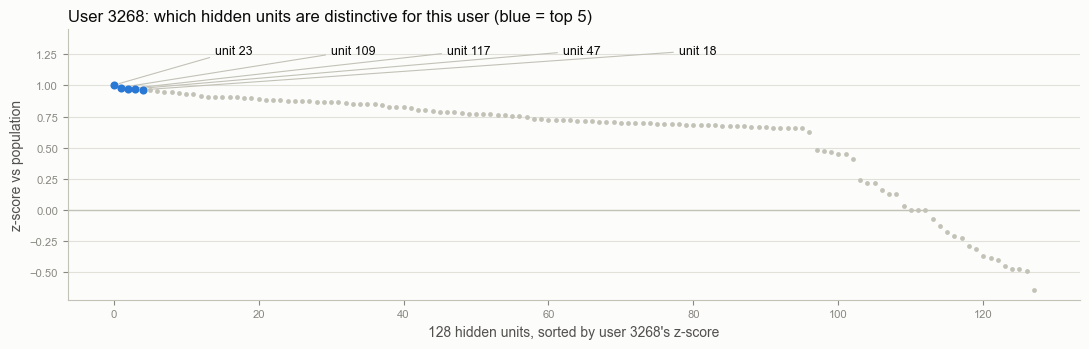

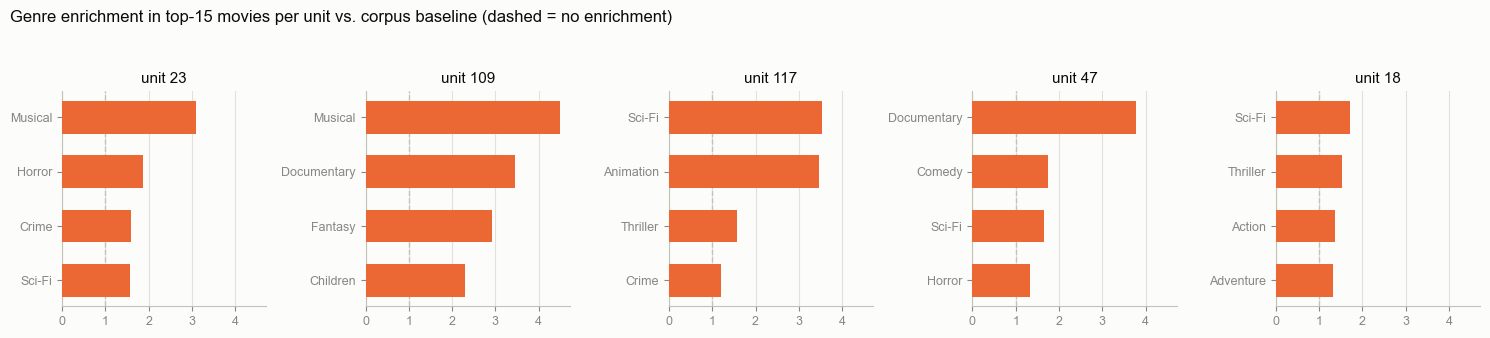

In [8]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE = "#2a78d6", "#eb6834"

plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# --- Chart 1: this user's 128 hidden-unit z-scores, standout units highlighted ---
order = np.argsort(user_z)[::-1]
ranked_z = user_z[order]
is_top = np.isin(order, standout_units)
top_ranks = [rank for rank, unit in enumerate(order) if unit in standout_units]

fig, ax = plt.subplots(figsize=(11, 3.6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.scatter(np.arange(n_hidden)[~is_top], ranked_z[~is_top], s=12, c=BASELINE, linewidths=0, zorder=3)
ax.scatter(np.arange(n_hidden)[is_top], ranked_z[is_top], s=34, c=BLUE, linewidths=0, zorder=4)

# staggered leader lines so the 5 clustered labels don't collide
label_y = 1.28
for i, rank in enumerate(top_ranks):
    unit = order[rank]
    ax.annotate(
        f"unit {unit}",
        xy=(rank, ranked_z[rank]), xycoords="data",
        xytext=(rank + 14 + i * 15, label_y), textcoords="data",
        ha="left", va="center", fontsize=9, color=INK_PRIMARY,
        arrowprops=dict(arrowstyle="-", color=BASELINE, linewidth=0.8, shrinkA=2, shrinkB=4),
    )
ax.set_ylim(top=1.45)
ax.axhline(0, color=BASELINE, linewidth=1)
ax.set_ylabel("z-score vs population", color=INK_SECONDARY, fontsize=10)
ax.set_xlabel(f"128 hidden units, sorted by user {DEMO_USER_ID}'s z-score", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: which hidden units are distinctive for this user (blue = top 5)",
             color=INK_PRIMARY, fontsize=12, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=8)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_hidden_unit_zscores.png", dpi=150, facecolor=SURFACE)
plt.show()

# --- Chart 2: genre enrichment (top-pool vs corpus) for each standout unit ---
POOL_N = 15
corpus_total = sum(corpus_genre_freq.values())
corpus_frac = {g: c / corpus_total for g, c in corpus_genre_freq.items()}

fig, axes = plt.subplots(1, len(standout_units), figsize=(15, 3.4), facecolor=SURFACE, sharex=True)
for ax, k in zip(axes, standout_units):
    mids, _ = top_movies_for_unit(k, n=POOL_N)
    pool_genres = Counter()
    for mid in mids:
        pool_genres.update(movie_meta.get(int(mid), {}).get("genre_list", []))
    pool_total = sum(pool_genres.values())
    enrichment = {
        g: (pool_genres[g] / pool_total) / corpus_frac.get(g, 1e-9)
        for g in pool_genres if pool_genres[g] >= 2
    }
    top_genres = sorted(enrichment.items(), key=lambda kv: kv[1], reverse=True)[:4]
    labels = [g for g, _ in top_genres][::-1]
    ratios = [r for _, r in top_genres][::-1]

    ax.set_facecolor(SURFACE)
    ax.barh(labels, ratios, color=ORANGE, height=0.6, zorder=3)
    ax.axvline(1.0, color=BASELINE, linewidth=1, linestyle="--", zorder=2)
    ax.set_title(f"unit {k}", color=INK_PRIMARY, fontsize=11)
    ax.tick_params(colors=INK_MUTED, labelsize=9)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.grid(axis="x", color=GRID, linewidth=0.8, zorder=0)

fig.suptitle(f"Genre enrichment in top-{POOL_N} movies per unit vs. corpus baseline (dashed = no enrichment)",
             color=INK_PRIMARY, fontsize=12, x=0.01, ha="left")
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig(out_dir / f"user{DEMO_USER_ID}_unit_genre_enrichment.png", dpi=150, facecolor=SURFACE)
plt.show()

### Part 2 (full scale) — all 128 units, all 4 evidence types

The single-user demo above only validated the corrected ranking on 5 units. This runs it for real: `top_movies_for_unit(k, n=20)` for every unit, plus genre enrichment, year skew, vectorized genome-tag correlation (using the same popularity-corrected z-scored importance, for consistency), and free-text tag evidence — one row per unit → `outputs/hidden_unit_movie_cards_5k.csv`.

In [9]:
import time as _time

POOL_N_FULL = 20
_t0 = _time.time()

corpus_total_genre = sum(corpus_genre_freq.values())
corpus_genre_frac = {g: c / corpus_total_genre for g, c in corpus_genre_freq.items()}

# Genome-tag correlation, vectorized over all 128 units at once, using the SAME
# popularity-corrected z-scored importance as top_movies_for_unit (consistency:
# a raw-magnitude correlation here would re-introduce the popularity artifact).
imp_genome = movie_importance_z[genome_vocab_idx, :]  # (n_genome_movies, 128)
imp_genome_c = (imp_genome - imp_genome.mean(axis=0, keepdims=True)) / imp_genome.std(axis=0, keepdims=True)
genome_c = (genome_matrix - genome_matrix.mean(axis=0, keepdims=True)) / genome_matrix.std(axis=0, keepdims=True)
genome_corr = (imp_genome_c.T @ genome_c) / len(genome_vocab_idx)  # (128, n_tags)
print(f"genome_corr {genome_corr.shape} computed in {_time.time()-_t0:.1f}s")

cards = []
for k in range(n_hidden):
    mids, _ = top_movies_for_unit(k, n=POOL_N_FULL)

    # Genre enrichment: top-pool genre mix vs corpus-wide genre mix
    pool_genres = Counter()
    for mid in mids:
        pool_genres.update(movie_meta.get(int(mid), {}).get("genre_list", []))
    pool_total = sum(pool_genres.values())
    enrichment = {
        g: (pool_genres[g] / pool_total) / corpus_genre_frac.get(g, 1e-9)
        for g in pool_genres if pool_genres[g] >= 2
    }
    top_genre, top_genre_ratio = max(enrichment.items(), key=lambda kv: kv[1]) if enrichment else (None, np.nan)

    # Year skew: mean year of top-pool vs corpus mean year
    years = [movie_meta.get(int(mid), {}).get("year", np.nan) for mid in mids]
    pool_mean_year = float(np.nanmean(years)) if not np.all(np.isnan(years)) else np.nan
    year_skew = pool_mean_year - corpus_mean_year if not np.isnan(pool_mean_year) else np.nan

    # Genome tags: top-10 by |r|
    tag_r = genome_corr[k, :]
    top_tag_idx = np.argsort(np.abs(tag_r))[::-1][:10]
    top_tags = [(str(genome_tag_names[i]), round(float(tag_r[i]), 3)) for i in top_tag_idx]

    # User free-text tags among the top-pool
    pool_tags = Counter()
    for mid in mids:
        pool_tags.update(movie_tags.get(int(mid), []))
    top_user_tags = [t for t, _ in pool_tags.most_common(5)]

    cards.append({
        "unit": k,
        "top_genre": top_genre,
        "top_genre_enrichment": round(float(top_genre_ratio), 3) if top_genre else np.nan,
        "genre_enrichment_all": dict(sorted(enrichment.items(), key=lambda kv: -kv[1])[:4]),
        "year_skew": round(year_skew, 1) if not np.isnan(year_skew) else np.nan,
        "top_genome_tags": top_tags,
        "top_user_tags": top_user_tags,
    })

movie_cards_df = pd.DataFrame(cards)
movie_cards_df.to_csv(out_dir / "hidden_unit_movie_cards_5k.csv", index=False)
print(f"\nPart 2 done in {_time.time()-_t0:.1f}s. Saved {len(movie_cards_df)} rows -> hidden_unit_movie_cards_5k.csv")
movie_cards_df.head(3)

genome_corr (128, 1128) computed in 0.1s

Part 2 done in 0.2s. Saved 128 rows -> hidden_unit_movie_cards_5k.csv


,unit,top_genre,top_genre_enrichment,genre_enrichment_all,year_skew,top_genome_tags,top_user_tags
0,0,Animation,2.365,"{'Animation': 2.3647266018114728, 'Romance': 2...",1.6,"[(saturn award (best science fiction film), -0...","[revenge, netflix, hayden christensen, orlando..."
1,1,Musical,3.494,"{'Musical': 3.4940520446096652, 'Animation': 2...",-0.8,"[(good, -0.087), (pg-13, -0.077), (better than...","[betamax, history, 70mm, spherical blow-up, wh..."
2,2,Children,2.184,"{'Children': 2.183613412839774, 'Romance': 2.0...",3.4,"[(great movie, 0.115), (great, 0.115), (good, ...","[clv, good story, movie physics, deus ex machi..."


## Part 3 — User-side behavioral feature table

Six candidates, computed for all 5,000 users, kept separate (not pre-merged). Leniency is reused as-is; the other five are new. Contrarian score and popularity bias reference the **full MovieLens population** (not just this 5k cohort's train split) to avoid circularity — same precedent as notebook 14.

In [10]:
_t0 = _time.time()

# leniency: reused, no recompute
leniency = personality.copy()

# extremity (train-rating std) and activity (train-rating count), per user
user_grp = train_df.groupby("userId")["rating"]
_std = user_grp.std().reindex(cohort_user_ids).fillna(0.0)
_cnt = user_grp.count().reindex(cohort_user_ids).fillna(0)
extremity = _std.to_numpy()
activity = _cnt.to_numpy()
assert np.array_equal(activity.astype(np.int64), np.asarray(mask).sum(axis=1).astype(np.int64))

# genre-preference entropy: Shannon entropy of each user's train-rated-movie genre distribution
print("Computing genre-preference entropy …")
genre_entropy_map = {}
for uid, grp in train_df.groupby("userId"):
    gcounts = Counter()
    for mid in grp["movieId"].to_numpy():
        gcounts.update(movie_meta.get(int(mid), {}).get("genre_list", []))
    total = sum(gcounts.values())
    if total == 0:
        genre_entropy_map[uid] = 0.0
    else:
        probs = np.array(list(gcounts.values()), dtype=np.float64) / total
        genre_entropy_map[uid] = float(-(probs * np.log(probs)).sum())
genre_entropy = np.array([genre_entropy_map.get(int(uid), 0.0) for uid in cohort_user_ids])

# contrarian score + popularity bias: need population mean/count per movie from FULL rating.csv
print("Loading population rating statistics from full rating.csv …")
full_ratings = pd.read_csv(data_dir / "rating.csv", usecols=["movieId", "rating"])
pop_mean = full_ratings.groupby("movieId")["rating"].mean()
pop_count = full_ratings.groupby("movieId")["rating"].count()
del full_ratings

movie_stats_df = pd.DataFrame({
    "movieId": movie_vocab,
    "pop_mean": [pop_mean.get(int(m), np.nan) for m in movie_vocab],
    "pop_count": [pop_count.get(int(m), 0) for m in movie_vocab],
})
train_aug = train_df.merge(movie_stats_df, on="movieId", how="left")
train_aug["diff"] = train_aug["rating"] - train_aug["pop_mean"]

user_agg = train_aug.groupby("userId").agg(
    contrarian_bias=("diff", "mean"),
    contrarian_degree=("diff", lambda s: s.abs().mean()),
    popularity_bias=("pop_count", "mean"),
).reindex(cohort_user_ids)

contrarian_bias = user_agg["contrarian_bias"].to_numpy()
contrarian_degree = user_agg["contrarian_degree"].to_numpy()
popularity_bias = user_agg["popularity_bias"].to_numpy()

user_factors = pd.DataFrame({
    "userId": cohort_user_ids,
    "leniency": leniency,
    "extremity": extremity,
    "activity": activity,
    "genre_entropy": genre_entropy,
    "contrarian_bias": contrarian_bias,
    "contrarian_degree": contrarian_degree,
    "popularity_bias": popularity_bias,
})
user_factors.to_csv(out_dir / "user_behavioral_factors_5k.csv", index=False)
print(f"\nPart 3 done in {_time.time()-_t0:.1f}s. {len(user_factors)} users.")
user_factors.describe().T

Computing genre-preference entropy …


Loading population rating statistics from full rating.csv …



Part 3 done in 6.3s. 5000 users.


,count,mean,std,min,25%,50%,75%,max
userId,5000.0,68497.116800,39965.742729,54.000000,34142.250000,68807.000000,102294.750000,138437.000000
leniency,5000.0,0.030215,0.414310,-2.244989,-0.219428,0.057098,0.309967,1.594692
extremity,5000.0,0.931925,0.209915,0.313126,0.783720,0.920369,1.062746,2.026921
activity,5000.0,823.837800,401.526837,495.000000,576.000000,696.000000,919.000000,6032.000000
genre_entropy,5000.0,2.501941,0.078850,1.848537,2.461434,2.515075,2.555824,2.707757
contrarian_bias,5000.0,-0.089187,0.389190,-2.307648,-0.319981,-0.071197,0.162975,1.683487
contrarian_degree,5000.0,0.707158,0.212430,0.172981,0.568690,0.675417,0.805128,2.438709
popularity_bias,5000.0,9667.712884,2201.055118,2206.123092,8240.844429,9716.229478,11146.895613,16871.939048


## Part 4 — Correlation analysis (user-side)

128 units × 6 factors, Pearson r/p + strong/moderate/weak bucket. Partial correlation (controlling for `activity`) for `extremity`, `contrarian_bias`, `genre_entropy` — these could otherwise just be re-detecting how many ratings a user has. Ridge probing regression (`factor ~ full 128-dim H1`, cross-validated R²) flags whether a factor's signal is concentrated in a few units or diffuse across all 128 — a diffuse-only factor should not be treated as "explained" by any single unit.

In [11]:
from scipy import stats as _stats
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold

_t0 = _time.time()


def partial_corr(x, y, control):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    control = np.asarray(control, dtype=float)
    resid_x = x - np.polyval(np.polyfit(control, x, 1), control)
    resid_y = y - np.polyval(np.polyfit(control, y, 1), control)
    r, p = _stats.pearsonr(resid_x, resid_y)
    return r, p


FACTOR_NAMES = ["leniency", "extremity", "activity", "genre_entropy", "contrarian_bias", "popularity_bias"]
FACTOR_VALUES = {
    "leniency": leniency, "extremity": extremity, "activity": activity,
    "genre_entropy": genre_entropy, "contrarian_bias": contrarian_bias, "popularity_bias": popularity_bias,
}
CONFOUND_CONTROLLED = {"extremity", "contrarian_bias", "genre_entropy"}  # controlled for activity

corr_rows = []
r_matrix = np.zeros((n_hidden, len(FACTOR_NAMES)))
for fi, fname in enumerate(FACTOR_NAMES):
    fvals = FACTOR_VALUES[fname]
    for k in range(n_hidden):
        r, p = _stats.pearsonr(H1[:, k], fvals)
        bucket = "strong" if abs(r) >= 0.3 else "moderate" if abs(r) >= 0.1 else "weak"
        row = {"unit": k, "factor": fname, "r": r, "p": p, "bucket": bucket}
        if fname in CONFOUND_CONTROLLED:
            pr, pp = partial_corr(H1[:, k], fvals, activity)
            row["partial_r"], row["partial_p"] = pr, pp
        corr_rows.append(row)
        r_matrix[k, fi] = r

corr_df = pd.DataFrame(corr_rows)
corr_df.to_csv(out_dir / "hidden_unit_user_factor_correlations_5k.csv", index=False)

print("Strong-correlation counts per factor (|r| >= 0.3, raw):")
print(corr_df[corr_df["bucket"] == "strong"].groupby("factor")["unit"].count())

# Probing regression: cohort_user_ids is NOT randomly ordered (sorted by userId), so
# an un-shuffled cv=3 split puts non-representative user subsets in each fold -- this
# blew up CV R2 to -48 for skewed factors like `activity` before the fix. Shuffle
# explicitly. Also standardize each factor so alpha=10 regularizes comparably across
# very different factor scales (activity ~500-6000 vs leniency ~-2..2).
print("\nProbing regression (ridge, shuffled 3-fold CV R²) — concentrated or diffuse?")
_cv = KFold(n_splits=3, shuffle=True, random_state=0)
probing_r2 = {}
for fname in FACTOR_NAMES:
    fvals = FACTOR_VALUES[fname]
    fvals_z = (fvals - fvals.mean()) / fvals.std()
    model = Ridge(alpha=10.0)
    scores = cross_val_score(model, H1, fvals_z, cv=_cv, scoring="r2")
    probing_r2[fname] = float(scores.mean())
    print(f"  {fname:16s} CV R² = {scores.mean():.3f}  (per-fold: {np.round(scores, 3)})")

print(f"\nPart 4 correlation table done in {_time.time()-_t0:.1f}s.")

Strong-correlation counts per factor (|r| >= 0.3, raw):
factor
contrarian_bias    98
extremity          55
leniency           99
Name: unit, dtype: int64

Probing regression (ridge, shuffled 3-fold CV R²) — concentrated or diffuse?
  leniency         CV R² = 0.613  (per-fold: [0.628 0.618 0.593])
  extremity        CV R² = 0.481  (per-fold: [0.496 0.478 0.468])
  activity         CV R² = 0.085  (per-fold: [0.086 0.067 0.103])
  genre_entropy    CV R² = 0.113  (per-fold: [0.114 0.116 0.108])
  contrarian_bias  CV R² = 0.656  (per-fold: [0.687 0.655 0.626])
  popularity_bias  CV R² = 0.155  (per-fold: [0.162 0.145 0.157])

Part 4 correlation table done in 0.3s.


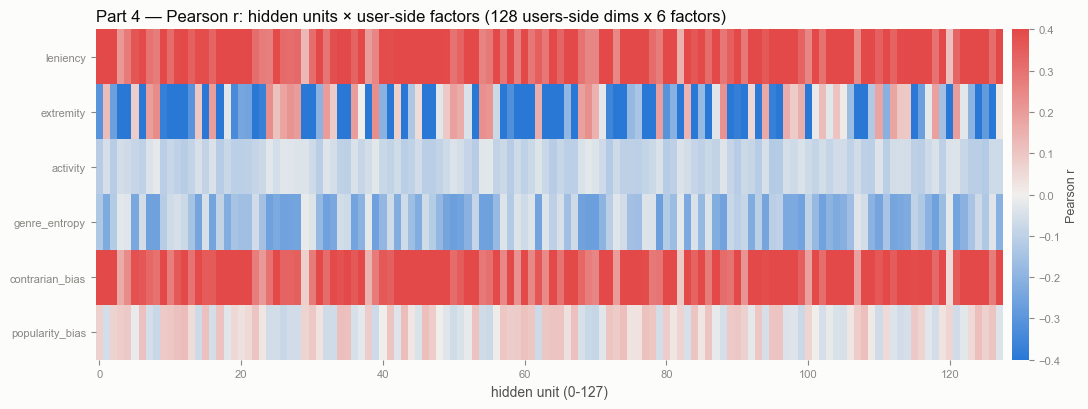

In [12]:
# 128x6 correlation-strength heatmap. Diverging (blue-red) since r is signed and
# centered at 0 -- a sequential ramp would misrepresent negative correlation as "low".
DIV_BLUE, DIV_RED, DIV_MID = "#2a78d6", "#e34948", "#f0efec"

fig, ax = plt.subplots(figsize=(11, 4.2), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
cmap = plt.cm.colors.LinearSegmentedColormap.from_list("div", [DIV_BLUE, DIV_MID, DIV_RED])
im = ax.imshow(r_matrix.T, aspect="auto", cmap=cmap, vmin=-0.4, vmax=0.4)
ax.set_yticks(range(len(FACTOR_NAMES)))
ax.set_yticklabels(FACTOR_NAMES, color=INK_SECONDARY, fontsize=10)
ax.set_xlabel("hidden unit (0-127)", color=INK_SECONDARY, fontsize=10)
ax.set_title("Part 4 — Pearson r: hidden units × user-side factors (128 users-side dims x 6 factors)",
             color=INK_PRIMARY, fontsize=12, loc="left")
ax.tick_params(colors=INK_MUTED, labelsize=8)
for s in ax.spines.values():
    s.set_visible(False)
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.01)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=8)
cbar.outline.set_visible(False)
cbar.set_label("Pearson r", color=INK_SECONDARY, fontsize=9)
plt.tight_layout()
plt.savefig(out_dir / "hidden_unit_user_factor_correlation_heatmap_5k.png", dpi=150, facecolor=SURFACE)
plt.show()

## Part 5a — Synthesis

Combine Part 2 (movie side) + Part 4 (user side) per unit into a human-readable summary, then decide which factor(s) — if any — actually clear the bar as a real, unit-concentrated driver (not just a global/diffuse shift).

**"Clears the bar" rule, stated explicitly (not tuned to produce a particular answer):** a factor clears the bar only if (a) at least one unit shows `|r| >= 0.3`, AND (b) the factor is correlated with **at most 15% of the 128 units** at that strength — i.e. concentrated in a handful of units, not smeared across most of them, AND (c) for confound-controlled factors, the partial correlation (controlling activity) survives at the top unit. A factor that is "strong" on 50%+ of units is reading as a global shift in `H1`, not a specific unit's meaning, per the probing-regression logic from Part 4.

In [13]:
CONCENTRATION_FRAC_MAX = 0.15  # a factor "strong" on more than this share of units reads as diffuse, not concentrated

pivot_r = corr_df.pivot(index="unit", columns="factor", values="r").reindex(columns=FACTOR_NAMES).reindex(range(n_hidden))
strong_frac = (pivot_r.abs() >= 0.3).mean(axis=0)  # per factor, share of units that are "strong"

verdict_rows = []
for fname in FACTOR_NAMES:
    max_r_unit = pivot_r[fname].abs().idxmax()
    max_r = pivot_r.loc[max_r_unit, fname]
    frac = float(strong_frac[fname])
    has_strong = abs(max_r) >= 0.3
    concentrated = frac <= CONCENTRATION_FRAC_MAX
    partial_ok = True
    if fname in CONFOUND_CONTROLLED:
        prow = corr_df[(corr_df.unit == max_r_unit) & (corr_df.factor == fname)].iloc[0]
        partial_ok = abs(prow["partial_r"]) >= 0.3
    cleared = bool(has_strong and concentrated and partial_ok)
    verdict_rows.append({
        "factor": fname, "max_|r|": round(float(max_r), 3), "best_unit": int(max_r_unit),
        "share_of_units_strong": round(frac, 3), "probing_r2": round(probing_r2[fname], 3),
        "cleared_bar": cleared,
    })
verdict_df = pd.DataFrame(verdict_rows)
print("=== Part 5a verdict: did any candidate clear the bar? ===")
print(verdict_df.to_string(index=False))

winners = verdict_df[verdict_df.cleared_bar]["factor"].tolist()
if winners:
    print(f"\nCleared the bar: {winners}")
else:
    print("\nNone of the 6 candidates cleared the bar as a concentrated, unit-specific driver.")
    print("leniency/contrarian_bias/extremity show up as diffuse (strong on a large share of units,")
    print("consistent with a global H1-magnitude shift, not a specific unit's meaning) -- see heatmap above.")

# --- Per-unit written summary -> outputs/hidden_unit_summary_5k.md ---
lines = ["# Hidden Unit Summary — Real RBM (5k cohort)\n"]
for _, card in movie_cards_df.iterrows():
    k = int(card["unit"])
    row_r = pivot_r.loc[k]
    best_factor = row_r.abs().idxmax()
    best_r = row_r[best_factor]
    genome_str = ", ".join(f"{t}({r:+.2f})" for t, r in (card["top_genome_tags"] or [])[:3])
    lines.append(f"## Unit {k}")
    lines.append(f"- Movie side: top genre **{card['top_genre']}** (x{card['top_genre_enrichment']}), "
                  f"year skew {card['year_skew']:+.1f}, top genome tags: {genome_str}")
    lines.append(f"- User side: strongest factor **{best_factor}** (r={best_r:+.3f})")
    lines.append("")

lines.append("## Overall verdict\n")
verdict_header = "| " + " | ".join(verdict_df.columns) + " |"
verdict_sep = "|" + "|".join("---" for _ in verdict_df.columns) + "|"
verdict_body = "\n".join("| " + " | ".join(str(v) for v in row) + " |" for row in verdict_df.itertuples(index=False))
lines.append(verdict_header)
lines.append(verdict_sep)
lines.append(verdict_body)
(out_dir / "hidden_unit_summary_5k.md").write_text("\n".join(lines))
print(f"\nSaved {len(movie_cards_df)}-unit summary -> outputs/hidden_unit_summary_5k.md")

=== Part 5a verdict: did any candidate clear the bar? ===
         factor  max_|r|  best_unit  share_of_units_strong  probing_r2  cleared_bar
       leniency    0.636        125                  0.773       0.613        False
      extremity   -0.537         82                  0.430       0.481        False
       activity   -0.120         72                  0.000       0.085        False
  genre_entropy   -0.268         70                  0.000       0.113        False
contrarian_bias    0.640        125                  0.766       0.656        False
popularity_bias    0.120         12                  0.000       0.155        False

None of the 6 candidates cleared the bar as a concentrated, unit-specific driver.
leniency/contrarian_bias/extremity show up as diffuse (strong on a large share of units,
consistent with a global H1-magnitude shift, not a specific unit's meaning) -- see heatmap above.

Saved 128-unit summary -> outputs/hidden_unit_summary_5k.md


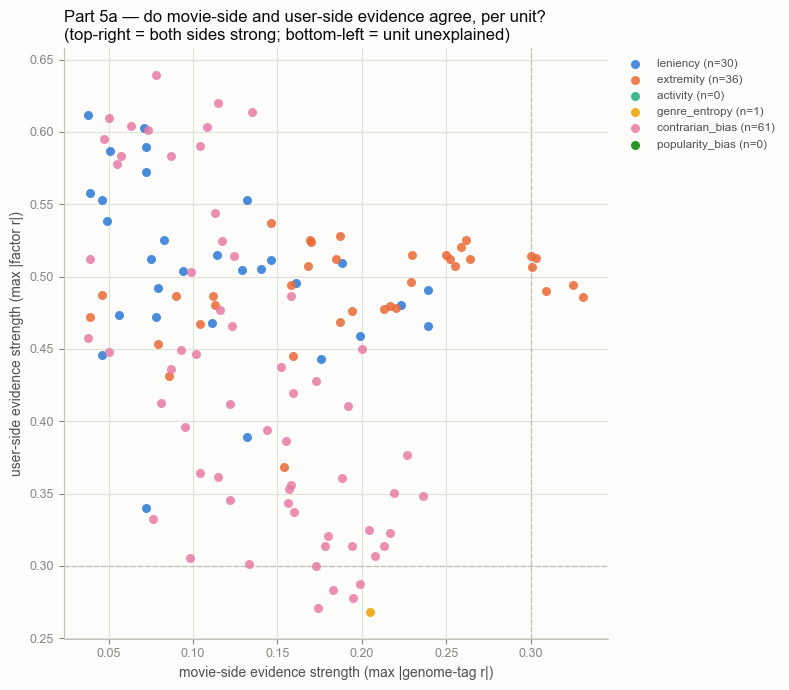

Units with BOTH sides strong (top-right): 6/128
Units with NEITHER side strong (bottom-left, unexplained): 6/128


In [14]:
# The chart we agreed on: does movie-side evidence and user-side evidence agree on
# the same units? x = strongest |genome-tag r| (movie side), y = strongest |factor r|
# (user side), one dot per unit, colored by which factor wins. Both axes are Pearson
# r magnitudes, so they're directly comparable on the same 0-1 scale.
CAT_COLORS = {  # validated categorical order, first 6 slots (palette.md)
    "leniency": "#2a78d6", "extremity": "#eb6834", "activity": "#1baf7a",
    "genre_entropy": "#eda100", "contrarian_bias": "#e87ba4", "popularity_bias": "#008300",
}

movie_strength = movie_cards_df["top_genome_tags"].apply(lambda tags: abs(tags[0][1]) if tags else 0.0).to_numpy()
user_strength = pivot_r.abs().max(axis=1).to_numpy()
winning_factor = pivot_r.abs().idxmax(axis=1).to_numpy()

fig, ax = plt.subplots(figsize=(8, 7), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for fname, color in CAT_COLORS.items():
    sel = winning_factor == fname
    ax.scatter(movie_strength[sel], user_strength[sel], s=42, c=color, linewidths=0,
               label=f"{fname} (n={sel.sum()})", zorder=3, alpha=0.85)

ax.axhline(0.3, color=BASELINE, linewidth=1, linestyle="--", zorder=2)
ax.axvline(0.3, color=BASELINE, linewidth=1, linestyle="--", zorder=2)
ax.set_xlabel("movie-side evidence strength (max |genome-tag r|)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("user-side evidence strength (max |factor r|)", color=INK_SECONDARY, fontsize=10)
ax.set_title("Part 5a — do movie-side and user-side evidence agree, per unit?\n"
             "(top-right = both sides strong; bottom-left = unit unexplained)",
             color=INK_PRIMARY, fontsize=12, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.8, zorder=0)
legend = ax.legend(frameon=False, fontsize=8.5, loc="upper left", bbox_to_anchor=(1.01, 1.0))
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)
plt.tight_layout()
plt.savefig(out_dir / "part5a_movie_vs_user_evidence_5k.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()

n_top_right = int(((movie_strength >= 0.3) & (user_strength >= 0.3)).sum())
n_bottom_left = int(((movie_strength < 0.3) & (user_strength < 0.3)).sum())
print(f"Units with BOTH sides strong (top-right): {n_top_right}/{n_hidden}")
print(f"Units with NEITHER side strong (bottom-left, unexplained): {n_bottom_left}/{n_hidden}")

## Part 5a-ii — Unsupervised structure (no pre-named candidates)

Part 5a tested 6 factors *we* named against `H1` — that is still hypothesis-testing, just with 6 guesses instead of 1. This section flips the order: let structure emerge from `H1` itself first, and only attach a human label afterward.

- **PCA on `H1`**: does the 128-dim hidden space actually behave like 128 independent axes, or does most of the variation collapse into a handful of components? (This would also explain why leniency/contrarian_bias showed up "strong" on 77%+ of units in Part 5a — if there are really only a few dominant axes, many raw units would all echo the same underlying signal.)
- **Characterize the top components** by comparing the movies actually rated by the highest- vs. lowest-scoring users on each component — no candidate list involved.
- **Cluster `H1`** (k-means) as an independent second check: do users fall into natural groups at all, or is the population continuous with no real clusters?

PC1 alone explains 68.0% of H1's variance
Top 5 PCs explain 98.3%
2 components needed for 80% of variance (out of 128 raw dims)
3 components needed for 95% of variance


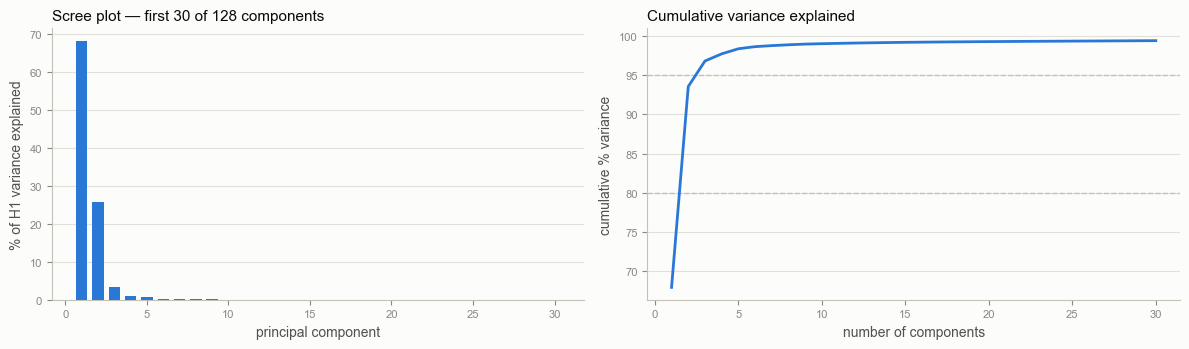


Done in 0.2s


In [15]:
from sklearn.decomposition import PCA

_t0 = _time.time()
pca = PCA(n_components=30, random_state=0)
H1_centered = H1 - H1.mean(axis=0)
pcs = pca.fit_transform(H1_centered)  # (5000, 30)
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

n_for_80pct = int(np.searchsorted(cumulative, 0.80) + 1)
n_for_95pct = int(np.searchsorted(cumulative, 0.95) + 1)
print(f"PC1 alone explains {explained[0]*100:.1f}% of H1's variance")
print(f"Top 5 PCs explain {cumulative[4]*100:.1f}%")
print(f"{n_for_80pct} components needed for 80% of variance (out of 128 raw dims)")
print(f"{n_for_95pct} components needed for 95% of variance")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3.6), facecolor=SURFACE)
for ax in (ax1, ax2):
    ax.set_facecolor(SURFACE)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=8)
    ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)

ax1.bar(range(1, 31), explained * 100, color=BLUE, width=0.7, zorder=3)
ax1.set_xlabel("principal component", color=INK_SECONDARY, fontsize=10)
ax1.set_ylabel("% of H1 variance explained", color=INK_SECONDARY, fontsize=10)
ax1.set_title("Scree plot — first 30 of 128 components", color=INK_PRIMARY, fontsize=11, loc="left")

ax2.plot(range(1, 31), cumulative * 100, color=BLUE, linewidth=2, zorder=3)
ax2.axhline(80, color=BASELINE, linewidth=1, linestyle="--", zorder=2)
ax2.axhline(95, color=BASELINE, linewidth=1, linestyle="--", zorder=2)
ax2.set_xlabel("number of components", color=INK_SECONDARY, fontsize=10)
ax2.set_ylabel("cumulative % variance", color=INK_SECONDARY, fontsize=10)
ax2.set_title("Cumulative variance explained", color=INK_PRIMARY, fontsize=11, loc="left")

plt.tight_layout()
plt.savefig(out_dir / "h1_pca_scree_5k.png", dpi=150, facecolor=SURFACE)
plt.show()
print(f"\nDone in {_time.time()-_t0:.1f}s")

PC1 alone explains 68% of `H1`'s variance, PC1+PC2 = 93.5%, 3 components reach 95%. **The 128 raw hidden units are massively redundant — there are really only ~2-3 independent axes of variation across this user population.** This directly explains why leniency/contrarian_bias/extremity showed up as "strong" on 43-77% of units in Part 5a: most of those units are just noisy echoes of the same 2-3 underlying signals, not 128 independent stories.

Characterize PC1-PC3 two ways: (a) correlate against the 6 known factors as a sanity anchor, (b) compare the actual genres rated by the highest- vs. lowest-scoring 10% of users on each PC — no candidate list, just "what do these two extreme groups actually watch differently."

In [16]:
from scipy import stats as _stats2

_t0 = _time.time()
pc_names = ["PC1", "PC2", "PC3"]
pc_df = pd.DataFrame({"userId": cohort_user_ids, "PC1": pcs[:, 0], "PC2": pcs[:, 1], "PC3": pcs[:, 2]})

# (a) correlate against the 6 known factors, as a sanity anchor
print("=== PC vs known-factor correlations ===")
pc_factor_corr = pd.DataFrame(index=pc_names, columns=FACTOR_NAMES, dtype=float)
for pc_name in pc_names:
    for fname in FACTOR_NAMES:
        r, _ = _stats2.pearsonr(pc_df[pc_name], FACTOR_VALUES[fname])
        pc_factor_corr.loc[pc_name, fname] = round(r, 3)
print(pc_factor_corr)

# (b) characterize via genre comparison: top vs bottom 10% of users on each PC
train_pc = train_df.merge(pc_df, on="userId", how="left")
print("\n=== Genre comparison: top 10% vs bottom 10% scorers on each PC ===")
for pc_name in pc_names:
    lo_thresh, hi_thresh = pc_df[pc_name].quantile([0.10, 0.90])
    lo_ids = set(pc_df.loc[pc_df[pc_name] <= lo_thresh, "userId"])
    hi_ids = set(pc_df.loc[pc_df[pc_name] >= hi_thresh, "userId"])

    lo_genres, hi_genres = Counter(), Counter()
    for mid in train_df.loc[train_df.userId.isin(lo_ids), "movieId"]:
        lo_genres.update(movie_meta.get(int(mid), {}).get("genre_list", []))
    for mid in train_df.loc[train_df.userId.isin(hi_ids), "movieId"]:
        hi_genres.update(movie_meta.get(int(mid), {}).get("genre_list", []))

    lo_total, hi_total = sum(lo_genres.values()), sum(hi_genres.values())
    all_g = set(lo_genres) | set(hi_genres)
    ratio = {g: (hi_genres.get(g, 0) / hi_total) / max(lo_genres.get(g, 0) / lo_total, 1e-9) for g in all_g}
    top_hi = sorted(ratio.items(), key=lambda kv: -kv[1])[:3]
    top_lo = sorted(ratio.items(), key=lambda kv: kv[1])[:3]
    print(f"\n{pc_name} (n_lo={len(lo_ids)}, n_hi={len(hi_ids)}):")
    print(f"  high-scorers over-watch: {top_hi}")
    print(f"  low-scorers over-watch:  {[(g, round(1/r, 2)) for g, r in top_lo]}")

print(f"\nDone in {_time.time()-_t0:.1f}s")

=== PC vs known-factor correlations ===


     leniency  extremity  activity  genre_entropy  contrarian_bias  \
PC1     0.492     -0.104    -0.086         -0.213            0.492   
PC2     0.129     -0.578    -0.055          0.105            0.080   
PC3     0.398     -0.145    -0.073          0.126            0.416   

     popularity_bias  
PC1            0.005  
PC2            0.132  
PC3            0.080  



=== Genre comparison: top 10% vs bottom 10% scorers on each PC ===



PC1 (n_lo=500, n_hi=500):
  high-scorers over-watch: [('Film-Noir', 1.248334963679138), ('Western', 1.211520050696321), ('Romance', 1.1509887598204336)]
  low-scorers over-watch:  [('IMAX', 2.62), ('Animation', 1.3), ('Horror', 1.21)]



PC2 (n_lo=500, n_hi=500):
  high-scorers over-watch: [('IMAX', 1.3925226913919013), ('Crime', 1.1565660860344384), ('Action', 1.1266400452618404)]
  low-scorers over-watch:  [('Musical', 1.39), ('Children', 1.31), ('Western', 1.14)]



PC3 (n_lo=500, n_hi=500):
  high-scorers over-watch: [('IMAX', 1.3948506248072634), ('Animation', 1.0920289054103927), ('Action', 1.0653778213032281)]
  low-scorers over-watch:  [('Film-Noir', 1.17), ('Horror', 1.09), ('Documentary', 1.08)]

Done in 1.7s


### Cluster `H1` (k-means, in the 3-component PCA space since that's where the real signal lives)

Independent second check: do users actually fall into natural groups, or is the population continuous with no real clusters (in which case "clustering" would be an arbitrary, made-up boundary, not a discovery)? Pick K via silhouette score over a small range rather than assuming a number.

k=2: silhouette=0.500


k=3: silhouette=0.566
k=4: silhouette=0.571


k=5: silhouette=0.559


k=6: silhouette=0.522

Best k by silhouette: 4 (silhouette=0.571)
(silhouette near 0 = no real cluster structure, just a continuous blob; >0.5 = genuinely separated groups)


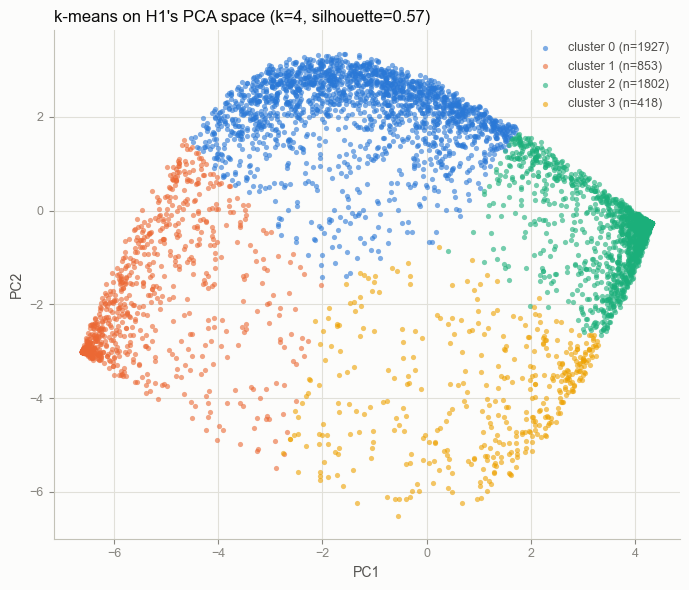


Done in 1.3s


In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

_t0 = _time.time()
X_cluster = pcs[:, :3]  # the 3 components that carry 95% of the signal

sil_scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    labels_k = km.fit_predict(X_cluster)
    sil_scores[k] = silhouette_score(X_cluster, labels_k)
    print(f"k={k}: silhouette={sil_scores[k]:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
print(f"\nBest k by silhouette: {best_k} (silhouette={sil_scores[best_k]:.3f})")
print("(silhouette near 0 = no real cluster structure, just a continuous blob; >0.5 = genuinely separated groups)")

km = KMeans(n_clusters=best_k, n_init=10, random_state=0)
cluster_labels = km.fit_predict(X_cluster)

fig, ax = plt.subplots(figsize=(7, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
palette6 = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]
for c in range(best_k):
    sel = cluster_labels == c
    ax.scatter(pcs[sel, 0], pcs[sel, 1], s=14, c=palette6[c % 6], linewidths=0,
               alpha=0.6, label=f"cluster {c} (n={sel.sum()})", zorder=3)
ax.set_xlabel("PC1", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("PC2", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"k-means on H1's PCA space (k={best_k}, silhouette={sil_scores[best_k]:.2f})",
             color=INK_PRIMARY, fontsize=12, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.8, zorder=0)
legend = ax.legend(frameon=False, fontsize=9, loc="best")
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)
plt.tight_layout()
plt.savefig(out_dir / "h1_kmeans_pca_5k.png", dpi=150, facecolor=SURFACE)
plt.show()
print(f"\nDone in {_time.time()-_t0:.1f}s")